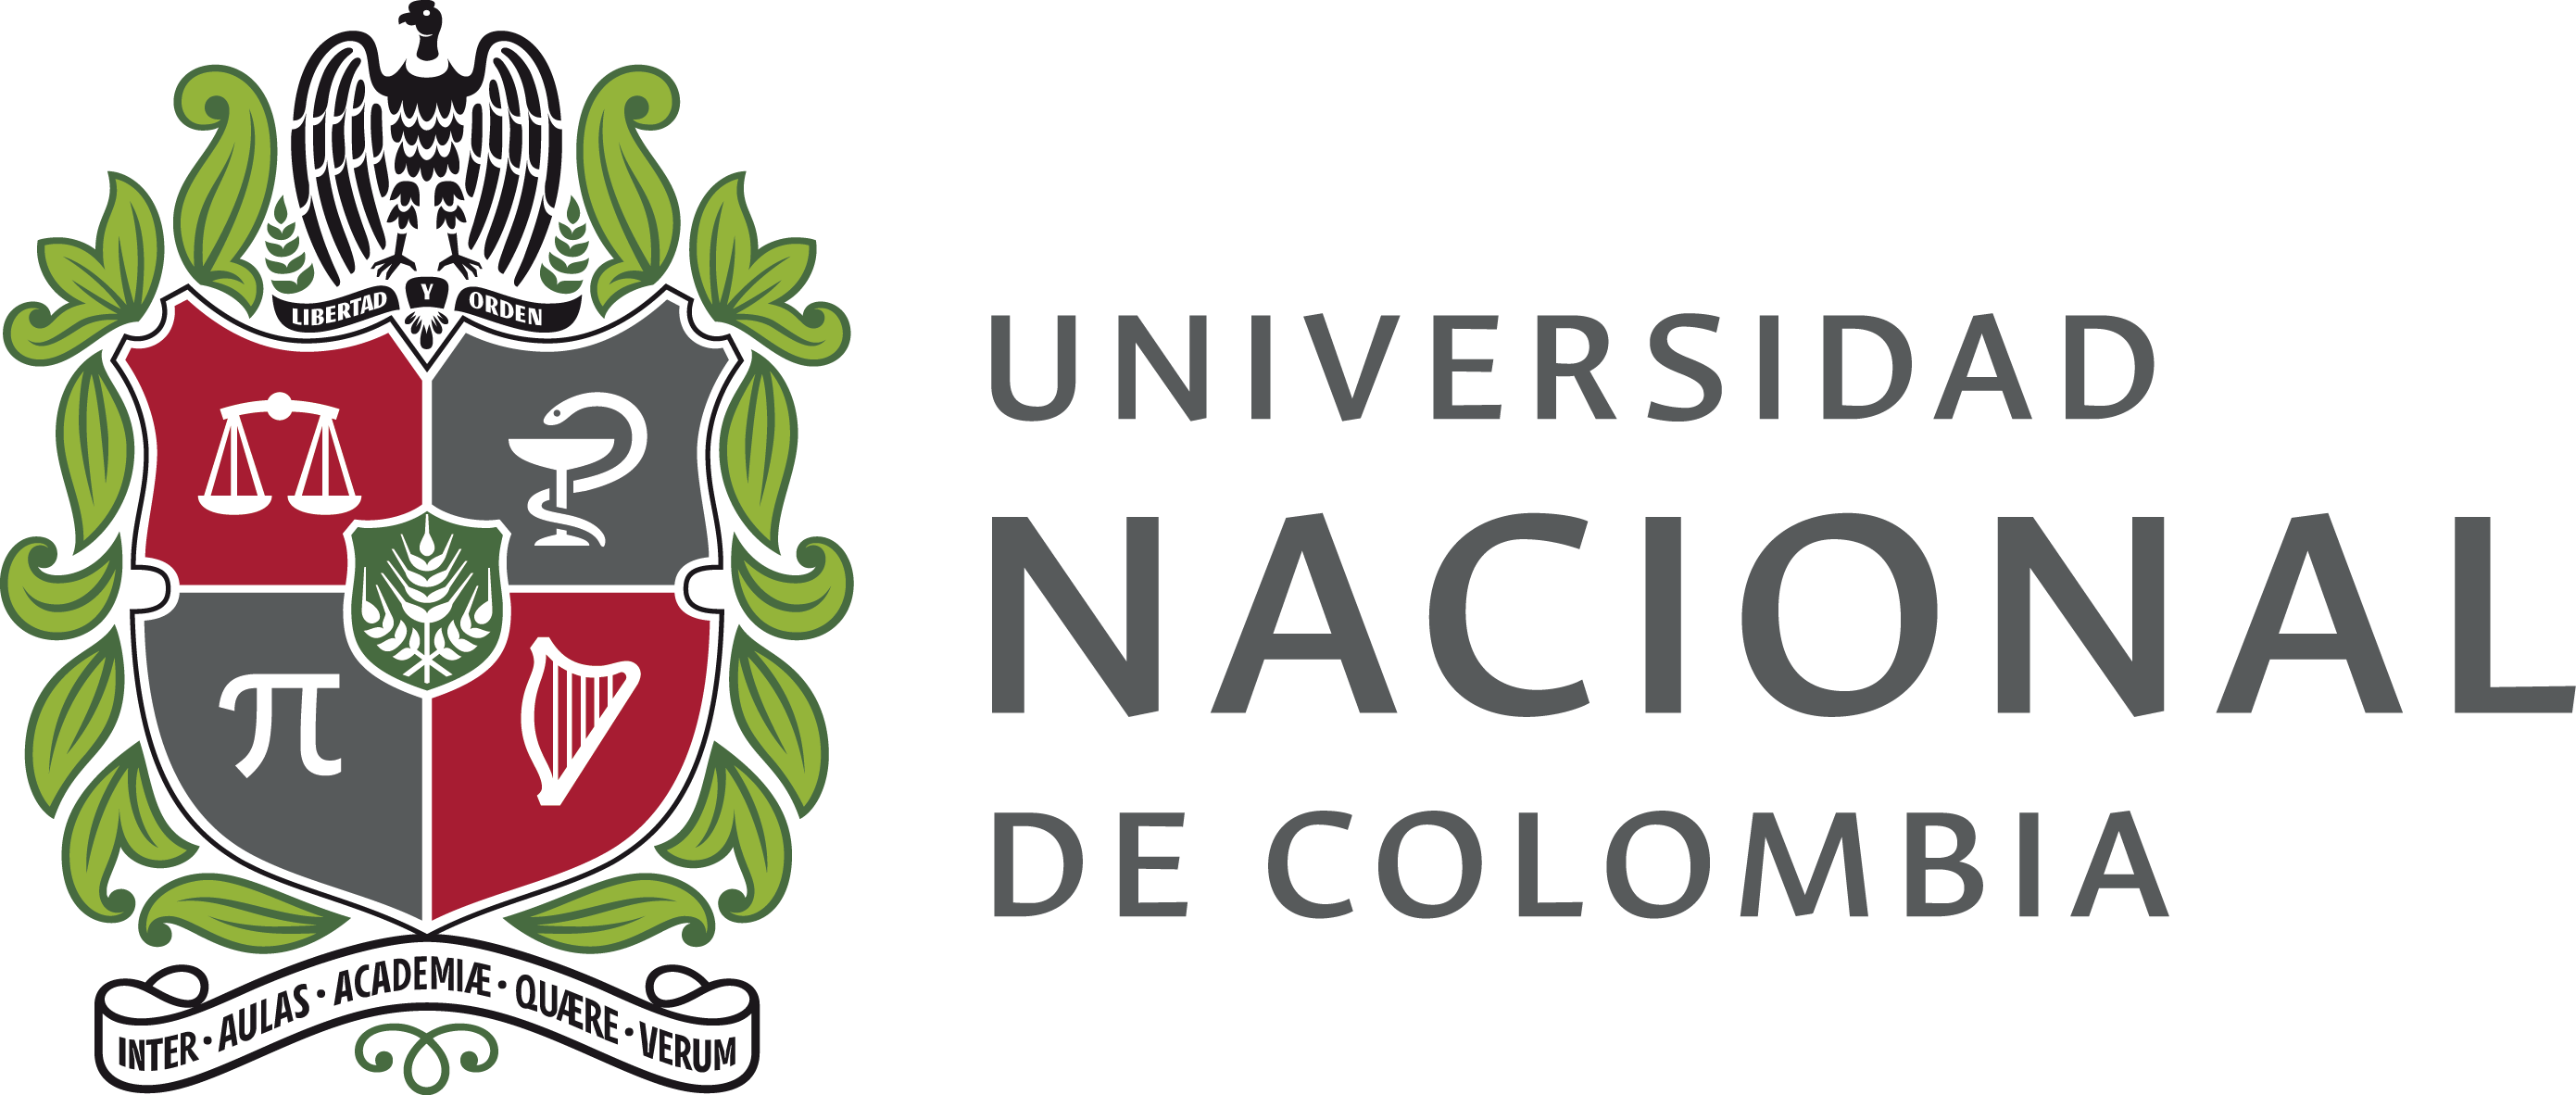
### **Universidad Nacional de Colombia sede Manizales**
#### Facultad de ingeniería y arquitectura
#### Departamento de ingeniería eléctrica, electrónica y computación
#### *Procesamiento digital de imágenes*

#### Profesor: Lucas Iturriago

In [1]:
%%capture
# Instalar y actualizar bibliotecas necesarias
!pip install roboflow
!pip install ultralytics
!pip install numpy==1.26.4

In [2]:
# Importar bibliotecas a usar y deshabilitar WanDB
import os
import yaml
import torch
import wandb
import shutil
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from roboflow import Roboflow
from ultralytics import YOLO

os.environ['WANDB_DISABLED'] = 'true'

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# Descargar base de datos
rf = Roboflow(api_key="9smAmQgaD8pNOTsDMYKR")
project = rf.workspace("roboflow-100").project("sign-language-sokdr")
version = project.version(2)
dataset = version.download("yolov11")
!mkdir datasets
!mv ./sign-language-2 ./datasets

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to sign-language-2 in yolov11:: 100%|██████████| 1452/1452 [00:01<00:00, 1051.24it/s]


In [4]:
# Creación del directorio de las partes de la base de datos
data = {
    'path': './sign-language-2',
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'names': {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',
              6:'G',7:'H',8:'I',9:'J',10:'K',11:'L',
              12:'M',13:'N',14:'O',15:'P',16:'Q',
              17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',
              23:'X',24:'Y',25:'Z'},
    'roboflow': {
        'license': 'CC BY 4.0',
        'project': 'sign-language-sokdr',
        'url': 'https://universe.roboflow.com/roboflow-100/sign-language-sokdr/dataset/2',
        'version': 2,
        'workspace': 'roboflow-100'}
}

# Especificar el directorio del archivo
file_path = './datasets/sign-language-2/data.yaml'

# Escribir la información sobre el archivo YAML
with open(file_path, 'w') as yaml_file:
    yaml.dump(data, yaml_file, default_flow_style=False)

In [5]:
# Entrenar YOLOv11 para detección

# Carga de modelo preentrenado
model = YOLO('yolo11m.pt')

# Entrenar el modelo
results = model.train(data='./datasets/sign-language-2/data.yaml', epochs=30, imgsz=128, device=[0,1])

Ultralytics 8.3.233 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
                                                       CUDA:1 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./datasets/sign-language-2/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=F

Ultralytics 8.3.233 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO11m summary (fused): 125 layers, 20,050,078 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3891.6±755.9 MB/s, size: 791.6 KB)
val: Scanning /kaggle/working/datasets/sign-language-2/valid/labels.cache... 144 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 144/144 332.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.4s/it 13.0s1.5s


invalid value encountered in less
invalid value encountered in less


                   all        144        144      0.964       0.77      0.879      0.834
                     A          5          5      0.667        0.4      0.598      0.539
                     B          9          9          1      0.667      0.833      0.778
                     C          3          3          1          1      0.995      0.895
                     D          6          6          1      0.833      0.917      0.883
                     E          4          4          1       0.75      0.875      0.854
                     F          8          8          1          1      0.995      0.964
                     G          5          5      0.833          1      0.995       0.96
                     H          9          9          1      0.778      0.889       0.84
                     I          2          2          1        0.5       0.75       0.75
                     J          8          8          1      0.625      0.812      0.652
                     

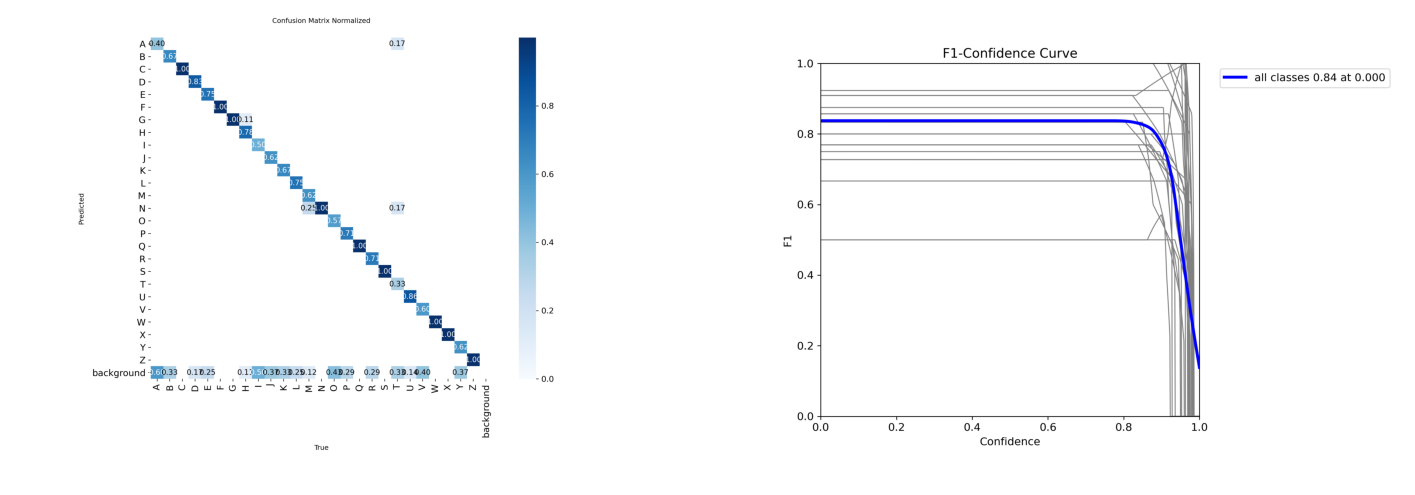

In [6]:
# Validar el modelo entrenado

# Carga de modelo entrenado
model = YOLO('./runs/detect/train/weights/best.pt') 

# Realizar validación
validation_results = model.val(data='./datasets/sign-language-2/data.yaml',
                               imgsz=128,
                               batch=16,
                               conf=0.8,
                               iou=0.6,
                               device='cpu')

# Cargar la imagen
image = mpimg.imread("./runs/detect/val/confusion_matrix_normalized.png")
image_1 = mpimg.imread("./runs/detect/val/BoxF1_curve.png")

# Mostrar la matriz de confusión imagen
fig, axis = plt.subplots(1,2,figsize=(18,8))
axis[0].imshow(image)
axis[0].axis('off')
axis[1].imshow(image_1)
axis[1].axis('off')
plt.show()

In [7]:
model.export(format='torchscript',dynamic=True)

Ultralytics 8.3.233 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 128, 128) BCHW and output shape(s) (1, 30, 336) (38.6 MB)

TorchScript: starting export with torch 2.6.0+cu124...
TorchScript: export success ✅ 2.9s, saved as 'runs/detect/train/weights/best.torchscript' (77.1 MB)

Export complete (3.0s)
Results saved to /kaggle/working/runs/detect/train/weights
Predict:         yolo predict task=detect model=runs/detect/train/weights/best.torchscript imgsz=128  
Validate:        yolo val task=detect model=runs/detect/train/weights/best.torchscript imgsz=128 data=./datasets/sign-language-2/data.yaml  
Visualize:       https://netron.app


'runs/detect/train/weights/best.torchscript'

In [8]:
# Cargar el modelo TorchScript (.pt o .ts)

ts_model = torch.jit.load("./runs/detect/train/weights/best.torchscript")
ts_model.eval()

# Crear un pseudo-tensor de entrada Shape: (batch=1, channels=3, height=128, width=128)
dummy_input = torch.randn(1, 3, 128, 128)

# Deshabilitar gradientes para mayor velocidad
with torch.no_grad():

    output = ts_model(dummy_input)

# Inspeccionar la salida
print("Output type:", type(output))
print("Output shape:", output.shape)

Output type: <class 'torch.Tensor'>
Output shape: torch.Size([1, 30, 336])


In [9]:
ts_wrapped_model = YOLO('./runs/detect/train/weights/best.torchscript')

Ultralytics 8.3.233 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon CPU @ 2.00GHz)
Loading ./runs/detect/train/weights/best.torchscript for TorchScript inference...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3440.3±2125.6 MB/s, size: 1057.1 KB)
val: Scanning /kaggle/working/datasets/sign-language-2/valid/labels.cache... 144 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 144/144 250.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 144/144 9.4it/s 15.4s0.1ss


invalid value encountered in less
invalid value encountered in less


                   all        144        144      0.964       0.77      0.879      0.834
                     A          5          5      0.667        0.4      0.598      0.539
                     B          9          9          1      0.667      0.833      0.778
                     C          3          3          1          1      0.995      0.895
                     D          6          6          1      0.833      0.917      0.883
                     E          4          4          1       0.75      0.875      0.854
                     F          8          8          1          1      0.995      0.964
                     G          5          5      0.833          1      0.995       0.96
                     H          9          9          1      0.778      0.889       0.84
                     I          2          2          1        0.5       0.75       0.75
                     J          8          8          1      0.625      0.812      0.652
                     

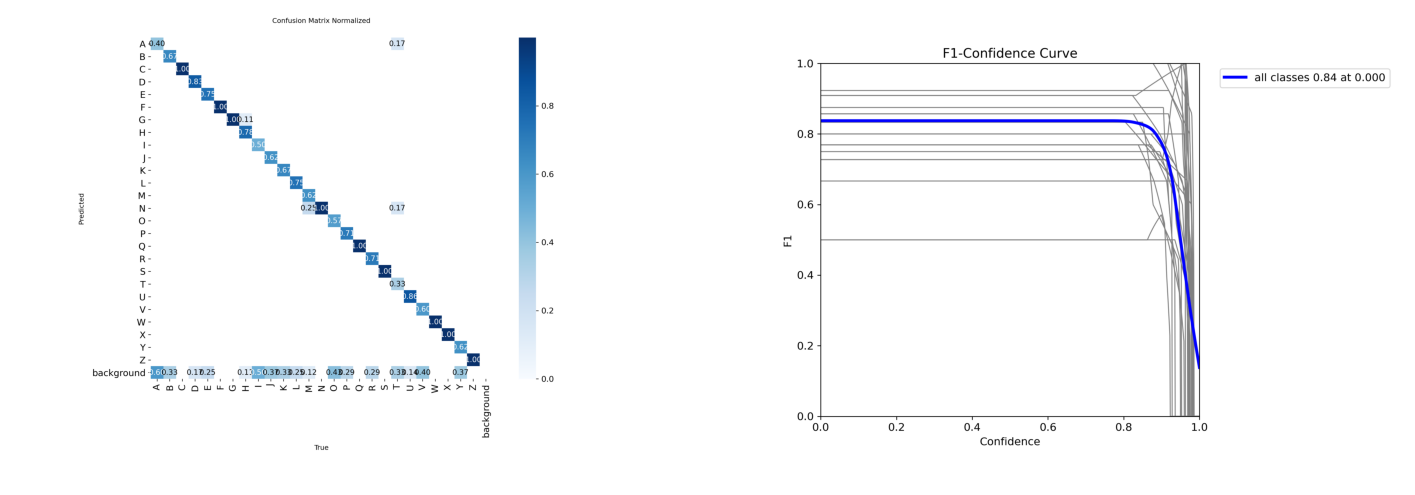

In [10]:
# Realizar validación
validation_results = ts_wrapped_model.val(data='./datasets/sign-language-2/data.yaml',
                               imgsz=128,
                               batch=1,
                               conf=0.8,
                               iou=0.6,
                               device='cpu')

# Cargar la imagen
image = mpimg.imread("./runs/detect/val2/confusion_matrix_normalized.png")
image_1 = mpimg.imread("./runs/detect/val2/BoxF1_curve.png")

# Mostrar la matriz de confusión imagen
fig, axis = plt.subplots(1,2,figsize=(18,8))
axis[0].imshow(image)
axis[0].axis('off')
axis[1].imshow(image_1)
axis[1].axis('off')
plt.show()